In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import os
import cv2

In [3]:
df_feats=pd.read_csv('X_train_update.csv')
df_target=pd.read_csv('Y_train_CVw08PX.csv')
df=df_feats.merge(df_target,on='Unnamed: 0',how='inner')
df.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)
cat=df_target['prdtypecode'].unique()
cat

array([  10, 2280,   50, 1280, 2705, 2522, 2582, 1560, 1281, 1920, 2403,
       1140, 2583, 1180, 1300, 2462, 1160, 2060,   40,   60, 1320, 1302,
       2220, 2905, 2585, 1940, 1301], dtype=int64)

In [4]:
df_feats.head(5)

,Unnamed: 0,designation,description,productid,imageid
0,0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786


In [5]:
df_target.head(5)

,Unnamed: 0,prdtypecode
0,0,10
1,1,2280
2,2,50
3,3,1280
4,4,2705


In [6]:
df['nom_image']=df.apply(lambda row: "image_" +  str(row['imageid']) 
                                     + "_product_" + str(row['productid']) + ".jpg",axis=1)
print("Nb enreg ", str(df.shape[0]))
df.head(5)
df_img=df.copy()

Nb enreg  84916


### test de lecture d'images

    Id                                        designation  \
2    2  Grand Stylet Ergonomique Bleu Gamepad Nintendo...   
31  31                                X-Men 3 - The Movie   
34  34                              The Lord Or Thé Rings   
40  40  Mini Console De Jeux Double Joueurs 8 Bits Con...   
47  47       Shin Masoukishin Panzer Warfare (Import Jap)   

                                          description   productid     imageid  \
2   PILOT STYLE Touch Pen de marque Speedlink est ...   201115110   938777978   
31                                                NaN    49132716   874730792   
34                                                NaN  4237073471  1324384878   
40  Nom de la marque:NoEnName_Null<br />Affichage ...  4200874030  1316147329   
47                                                NaN     8870838   868167157   

    prdtypecode                                nom_image  
2            50    image_938777978_product_201115110.jpg  
31           40     image_87

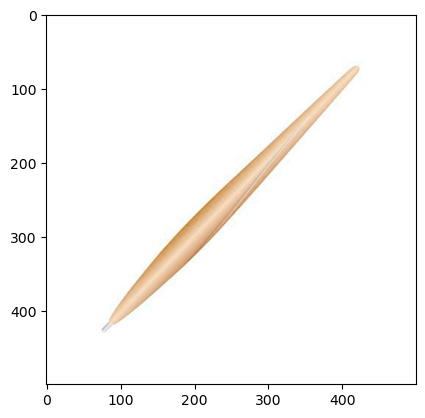

In [7]:
import os
import cv2
import numpy as np

from PIL import Image

# Définir le chemin du dossier contenant les images
folder_path = "C:\\Users\\MANUADMIN\\python\\DataScience\\Datascientest\\PROJET\\images\\image_train"

df_img=df[df['prdtypecode'].isin([40,50,60])]
print(df_img.head())

# Charger les images et les stocker dans un tableau
image_list = []


for filename in df_img['nom_image'][df_img['prdtypecode']==50]:
    #print(os.path.join(folder_path, filename))
    #image = Image.open(os.path.join(folder_path, filename))
    #image.show()
    img = cv2.imread(os.path.join(folder_path, filename))
    if img is not None:
        image_list.append(img)



# Convertir la liste d'images en un tableau numpy
images = np.array(image_list)
print(len(images))
print(images.shape)


# Afficher la première image
image=images[0,:,:,:]
plt.imshow(image)
plt.show()




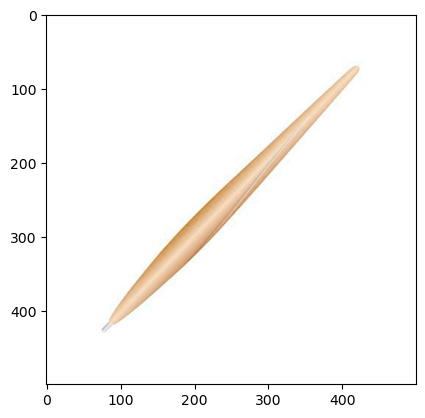

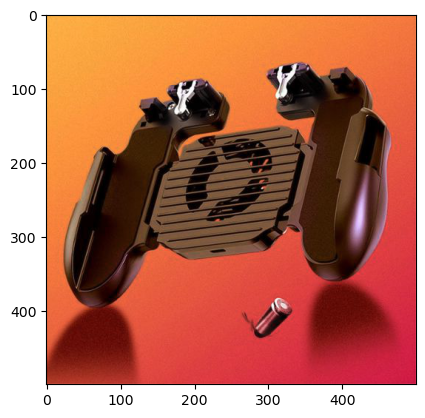

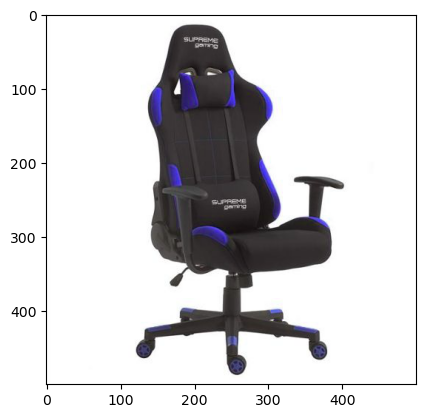

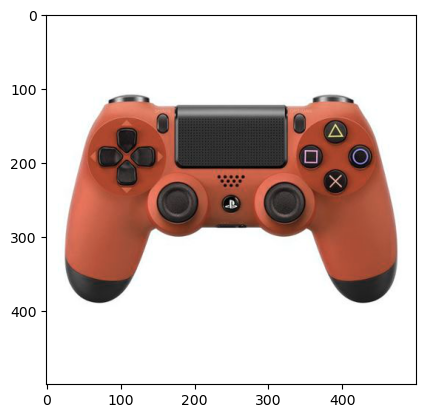

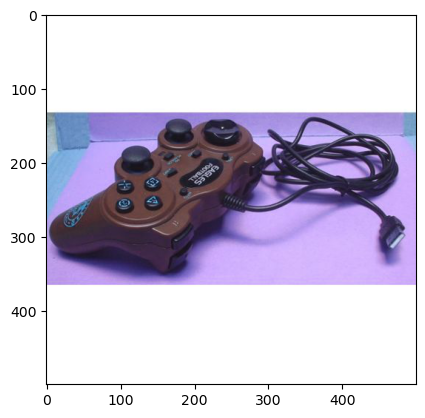

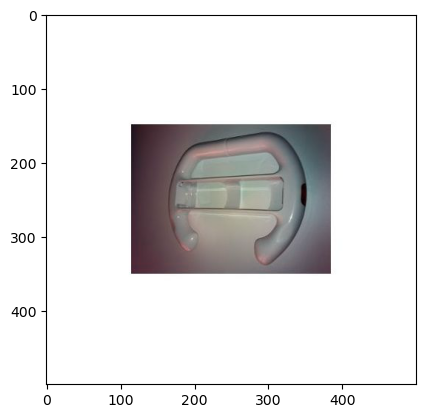

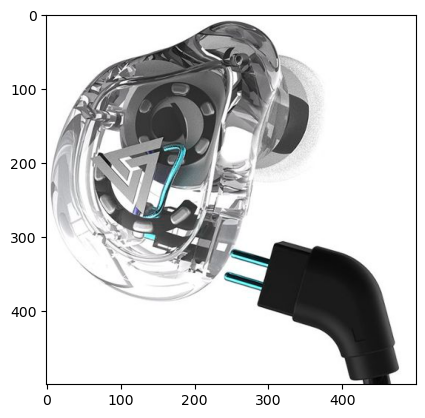

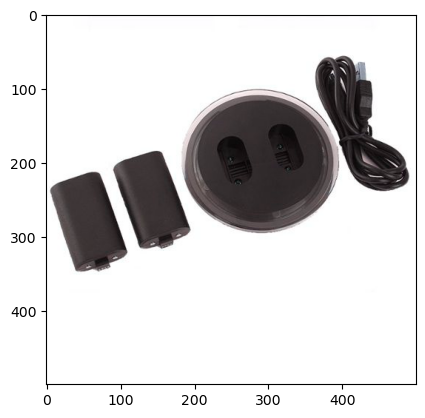

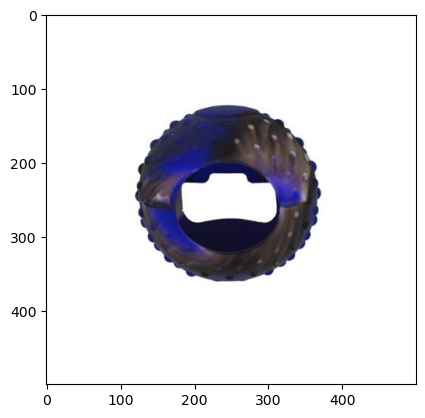

In [8]:
for i in range(9):
    image=images[i,:,:,:]
    plt.imshow(image)
    plt.show()

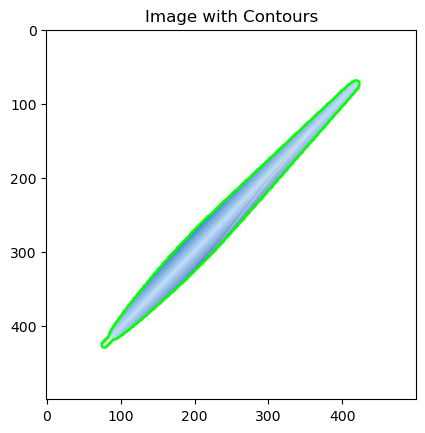

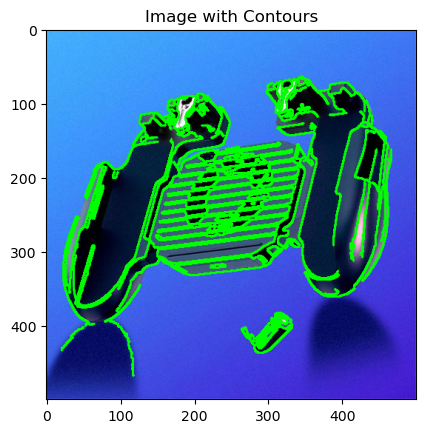

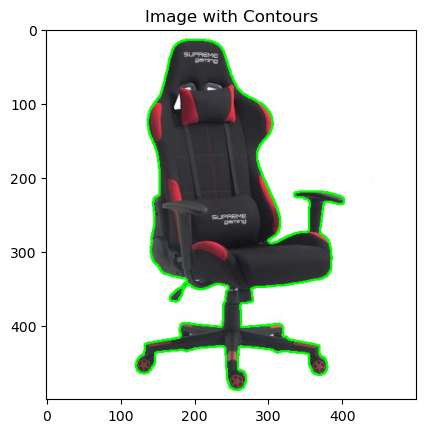

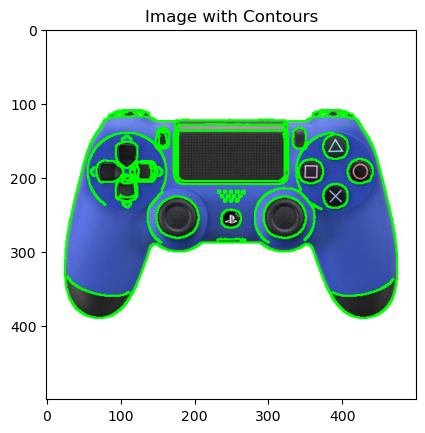

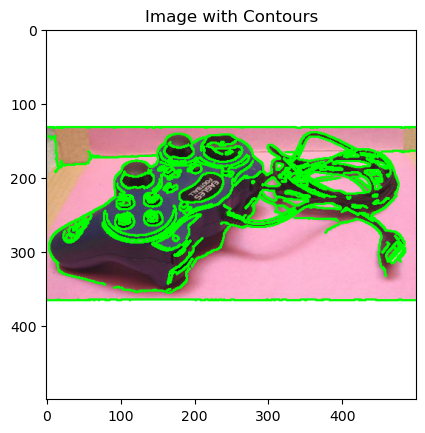

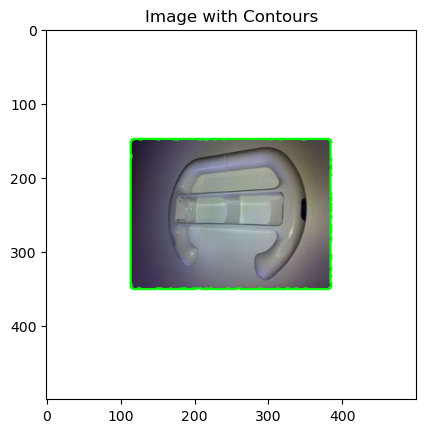

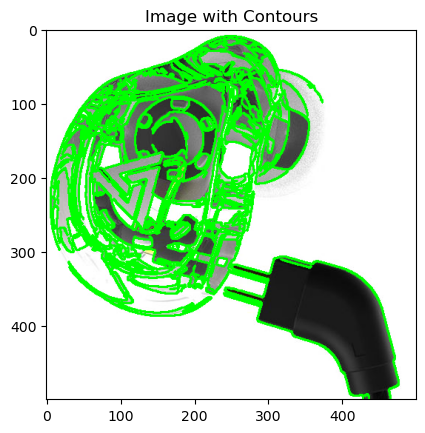

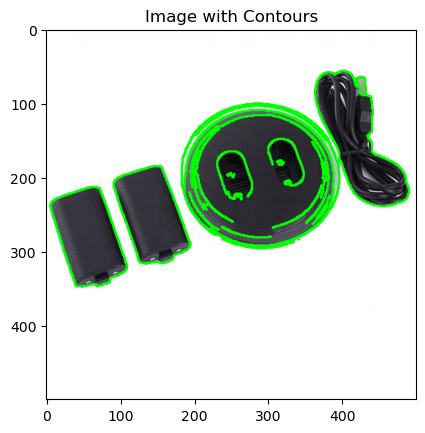

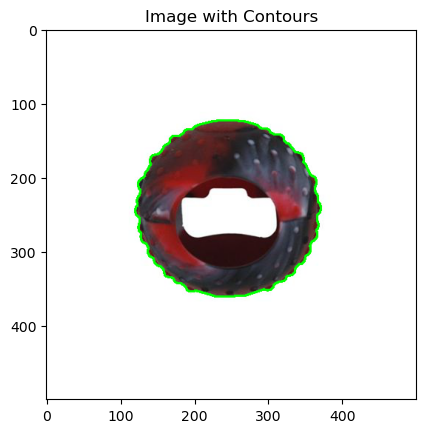

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_contours(image_path):
    # Lecture de l'image
    img = cv2.imread(image_path)

    # Convertir l'image en niveaux de gris
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Appliquer un flou pour réduire le bruit
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Appliquer une détection de bordure Canny
    edges = cv2.Canny(blurred, threshold1=30, threshold2=100)

    # Trouver les contours à partir des bords
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Dessiner tous les contours sur l'image originale
    cv2.drawContours(img, contours, -1, (0, 255, 0), 2)

    # Affichage de l'image avec les contours détectés
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  
    plt.title('Image with Contours')
    plt.show()


nomfic=[]   
for filename in df_img['nom_image'][df_img['prdtypecode']==50]:
    nomfic.append(os.path.join(folder_path, filename))
for i in range(9):
    image=nomfic[i]
    find_contours(image)   


Shape:  triangle


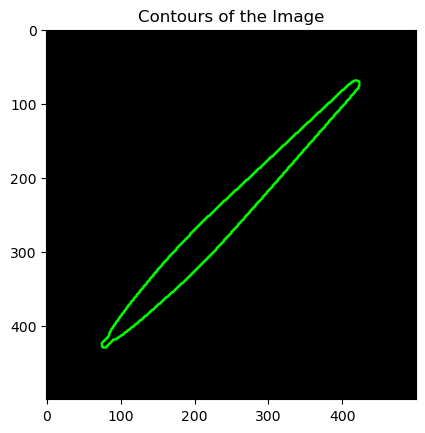

Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  pentagone
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  pentagone
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  hexagone
Shape:  hexagone
Shape:  pentagone
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  hexagone
Shape:  ligne
Shape:  ligne
Shape:  rectangle
Shape:  unknown
Shape:  ligne
Shape:  unknown
Shape:  ligne
Shape:  pentagone
Shape:  pentagone
Shape:  pentagone
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  pentagone
Shape:  ligne
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  ligne
Shape:  unknown
Shape:  rectangle
Shape:  ligne
Shape:  ligne
Shape:  hexagone
Shape:  lig

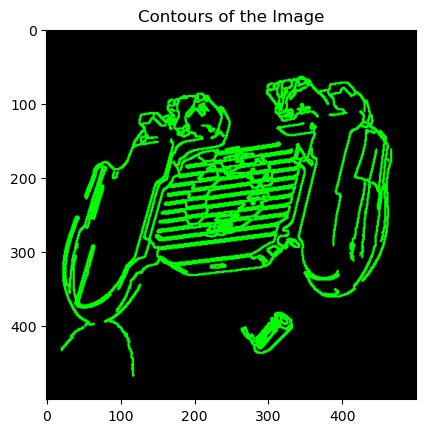

Shape:  unknown


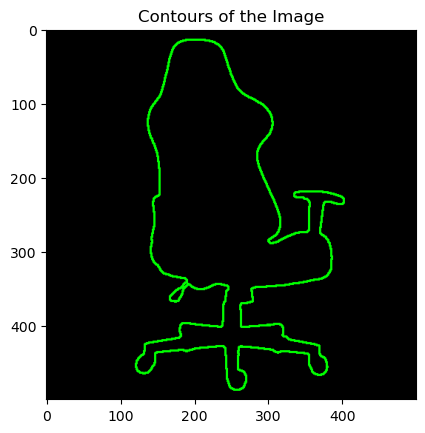

Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  ligne
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  rectangle
Shape:  hexagone
Shape:  rectangle
Shape:  hexagone
Shape:  hexagone
Shape:  hexagone
Shape:  rectangle
Shape:  rectangle
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  pentagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  pentagone
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  triangle
Shape:  unknown
Shape:  unknown


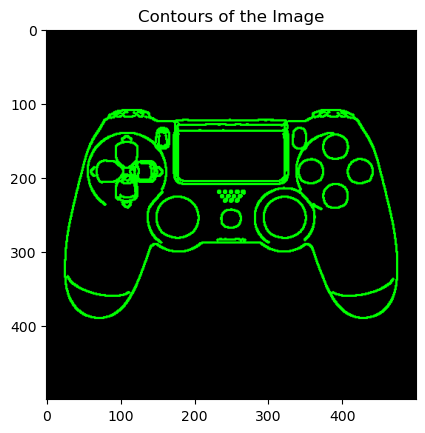

Shape:  ligne
Shape:  pentagone
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  rectangle
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unk

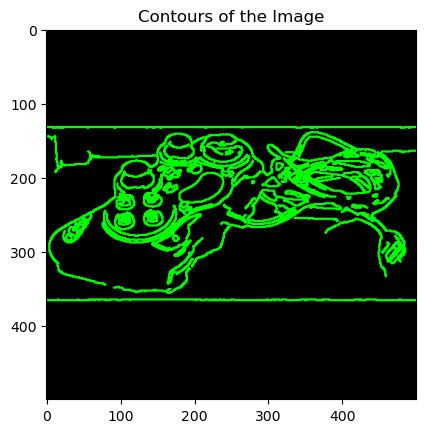

Shape:  rectangle


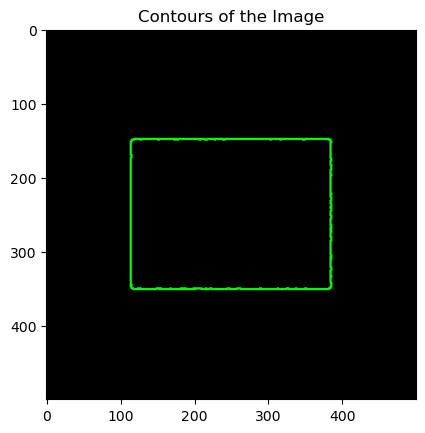

Shape:  unknown
Shape:  hexagone
Shape:  ligne
Shape:  ligne
Shape:  unknown
Shape:  ligne
Shape:  unknown
Shape:  ligne
Shape:  ligne
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  pentagone
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  hexagone
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  ligne
Shape:  ligne
Shape:  hexagone
Shape:  unknown
Shape:  ligne
Shape:  hexagone
Shape:  rectangle
Shape:  ligne
Shape:  ligne
Shape:  pentagone
Shape:  unknown
Shape:  rectangle
Shape:  ligne
Shape:  unknown
Shape:  unknown
Shape:  pentagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  pentagone
Shape:  pentagone
Shape:  unknown
Shape:  pentagone
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape: 

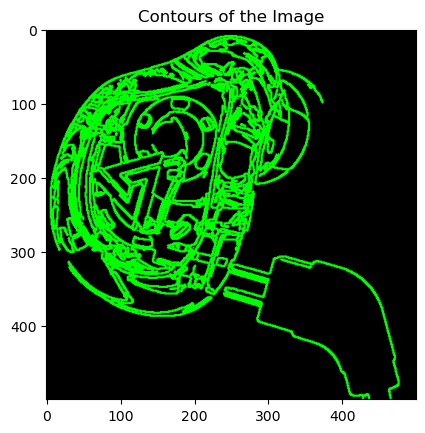

Shape:  rectangle
Shape:  ligne
Shape:  rectangle
Shape:  rectangle
Shape:  hexagone
Shape:  pentagone
Shape:  unknown
Shape:  pentagone
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  pentagone
Shape:  unknown
Shape:  unknown
Shape:  rectangle
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  unknown
Shape:  hexagone
Shape:  unknown


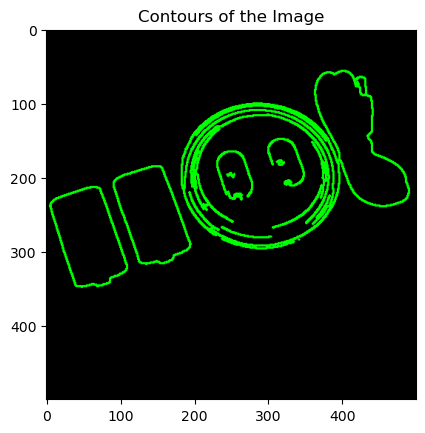

Shape:  unknown


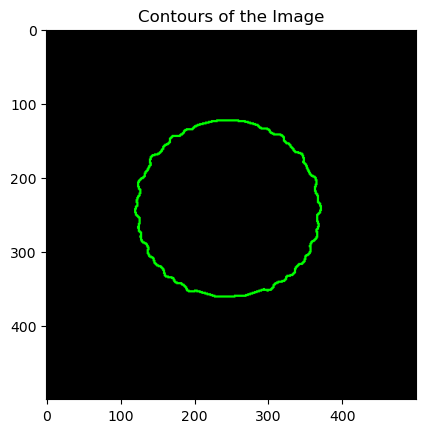

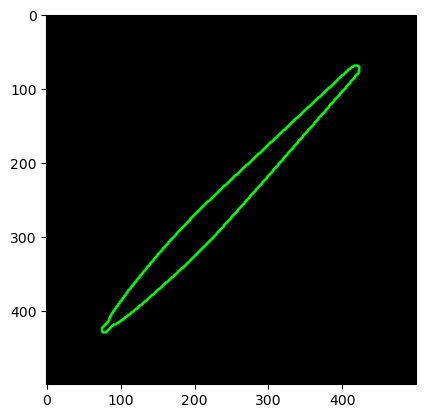

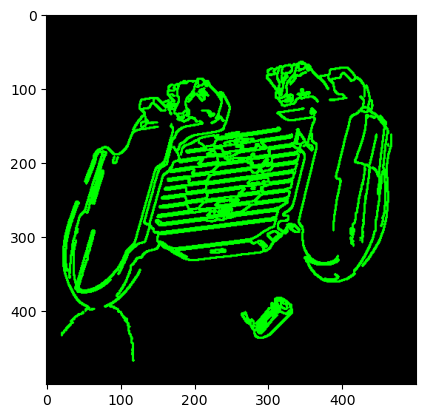

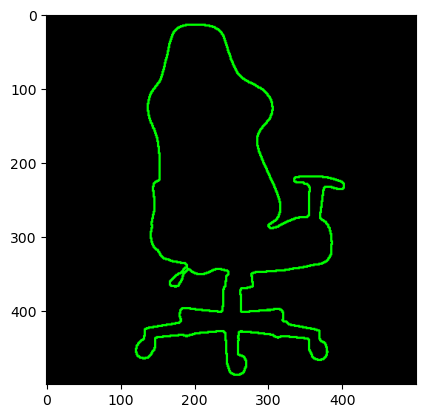

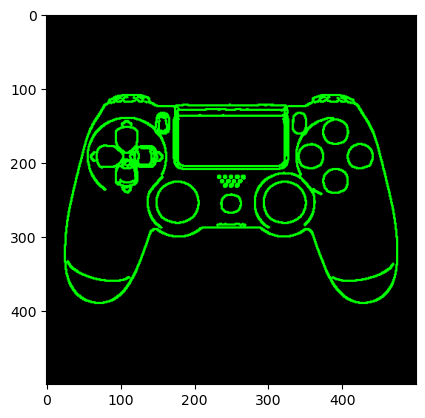

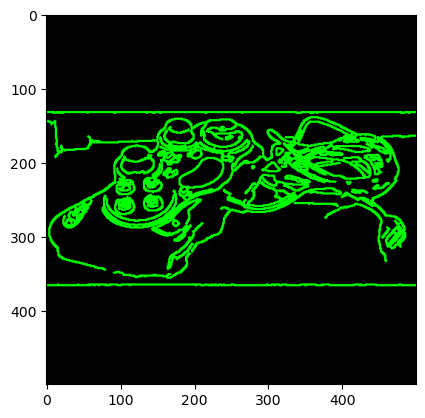

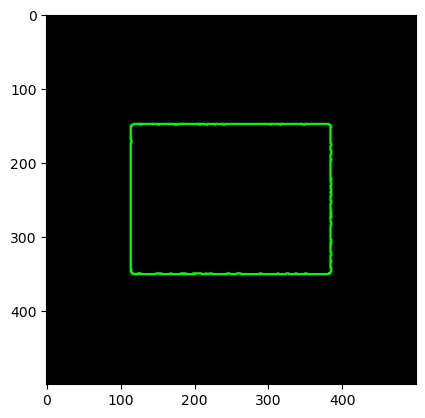

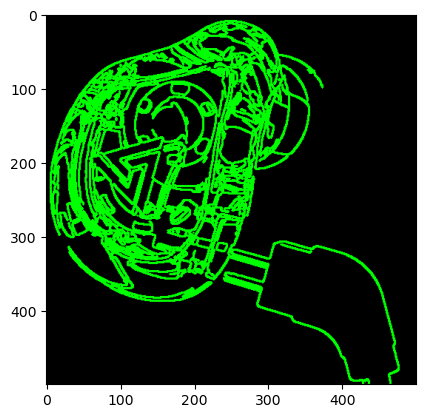

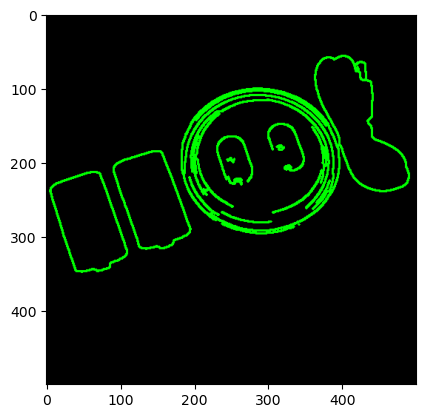

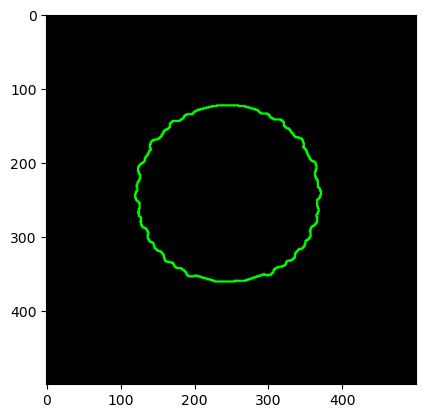

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Cimages=[]

def find_contours(image_path):
    # Lecture de l'image
    img = cv2.imread(image_path)
    img = np.uint8(img)

    # Convertir l'image en niveaux de gris
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Appliquer un flou pour réduire le bruit
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Appliquer une détection de bordure Canny
    edges = cv2.Canny(blurred, threshold1=30, threshold2=100)

    # Trouver les contours à partir des bords
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    classes = {0: 'cercle', 2: 'ligne', 3: 'triangle', 4: 'rectangle', 5: 'pentagone', 6: 'hexagone'}

    for contour in contours:
        # Approximer le contour
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        # Classer la forme en fonction du nombre de sommets
        num_vertices = len(approx)
        shape = classes.get(num_vertices, "unknown")

        print("Shape: ", shape)

    # Créer une image noire de la même taille que l'originale
    black_image = np.zeros(img.shape, np.uint8)

    # Dessiner les contours sur cette image noire
    cv2.drawContours(black_image, contours, -1, (0, 255, 0), 2)

    # Affichage de l'image avec les contours détectés
    Cimages.append(black_image)
    plt.imshow(cv2.cvtColor(black_image, cv2.COLOR_BGR2RGB))
    plt.title('Contours of the Image')
    plt.show()



nomfic=[]   
for filename in df_img['nom_image'][df_img['prdtypecode']==50]:
    nomfic.append(os.path.join(folder_path, filename))
for i in range(9):
    image=nomfic[i]
    find_contours(image)   
for i in range(9):
    plt.imshow(cv2.cvtColor(Cimages[i], cv2.COLOR_BGR2RGB))
    plt.show()
    

### test de contours d'images

In [48]:
Dfcontour=pd.DataFrame()
# Définir les classes de formes
classes = {0: 'cercle', 2: 'ligneE', 3: 'triangle', 4: 'rectangle', 5: 'pentagone', 6: 'hexagone'}
for i in range(len(images)):
    image=images[i,:,:,:]
    # Convertir l'image en niveaux de gris
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Appliquer un filtre pour réduire le bruit de l'image
    gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)
    # Détecter les contours de l'image
    edges = cv2.Canny(gray_blur, 50, 150, apertureSize=3)
    # Extraire les caractéristiques des contours détectés
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    shapes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0 :
            circularity = 0
        else :    
            circularity = 4 * np.pi * area / perimeter ** 2
        approx = cv2.approxPolyDP(cnt, 0.01 * perimeter, True)
        corners = len(approx)
        #print("---------------")
        #print(area,perimeter,circularity,corners)
        shapes.append((corners, circularity))
    if len(Dfcontour) == 0 :
        Dfcontour =pd.DataFrame(shapes, columns=['corners','circularity'])    
    else:
        Dfcontour = pd.concat([Dfcontour,pd.DataFrame(shapes, columns=['corners','circularity']) ]
                              ,ignore_index=True,axis=0)
print(Dfcontour.head())    
    

  corners  circularity
0       4     0.159347
1      16     0.044918
2      11     0.024504
3      14     0.700979
4      12     0.181577


In [49]:
print(Dfcontour.info())   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143109 entries, 0 to 143108
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   corners      143109 non-null  object 
 1   circularity  143109 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB
None


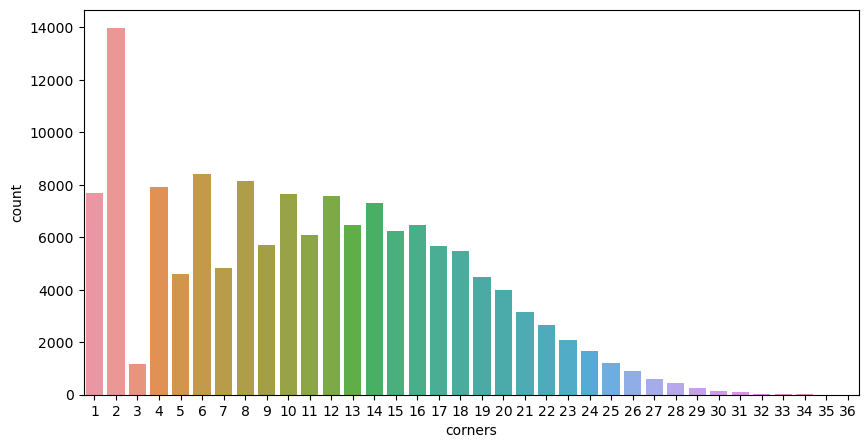

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.countplot(x=Dfcontour['corners'])
plt.show()

## Dataframe des contours

In [54]:
Dfcontour=pd.DataFrame()
for c in cat:
    print(c)
    for filename in df_img[df_img['prdtypecode']==c]['nom_image']:
        img = cv2.imread(os.path.join(folder_path, filename))
        if img is not None:
            image_list.append(img)
    images = np.array(image_list)
    for i in range(len(images)):
        image=images[i,:,:,:]
        # Convertir l'image en niveaux de gris
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Appliquer un filtre pour réduire le bruit de l'image
        gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)
        # Détecter les contours de l'image
        edges = cv2.Canny(gray_blur, 50, 150, apertureSize=3)
        # Extraire les caractéristiques des contours détectés
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        shapes = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0 :
                circularity = 0
            else :    
                circularity = 4 * np.pi * area / perimeter ** 2
            approx = cv2.approxPolyDP(cnt, 0.01 * perimeter, True)
            corners = len(approx)
            #print("---------------")
            #print(area,perimeter,circularity,corners)
            shapes.append((c,corners, circularity))
        if len(Dfcontour) == 0 :
            Dfcontour =pd.DataFrame(shapes, columns=['prdtypecode','corners','circularity'])    
        else:
            Dfcontour = pd.concat([Dfcontour,pd.DataFrame(shapes, columns=['prdtypecode','corners','circularity']) ]
                                  ,ignore_index=True,axis=0)
print(Dfcontour.head())    

10
2280
50
1280
2705
2522
2582
1560
1281
1920
2403
1140
2583
1180
1300
2462
1160
2060
40
60
1320
1302
2220
2905
2585
1940
1301
  prdtypecode corners  circularity
0          10       4     0.159347
1          10      16     0.044918
2          10      11     0.024504
3          10      14     0.700979
4          10      12     0.181577


In [55]:
Dfcontour.to_csv('Dfcontour.csv')

In [56]:
Dfcontour.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12962253 entries, 0 to 12962252
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   prdtypecode  object 
 1   corners      object 
 2   circularity  float64
dtypes: float64(1), object(2)
memory usage: 296.7+ MB


In [11]:
Dfcontour=pd.read_csv('Dfcontour.csv')
Dfcontour.info()
Dfcontour['prdtypecode'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12962253 entries, 0 to 12962252
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   prdtypecode  int64  
 2   corners      int64  
 3   circularity  float64
dtypes: float64(1), int64(3)
memory usage: 395.6 MB


1301    910280
1940    910280
2585    910280
2905    910280
2220    910280
1302    910280
1320    910280
60      910280
40      814307
1300    286218
2060    286218
1160    286218
2462    286218
1180    286218
2583    286218
1140    286218
2403    286218
1920    286218
1281    286218
1560    286218
2582    286218
2522    286218
2705    286218
1280    286218
50      286218
2280    143109
10      143109
Name: prdtypecode, dtype: int64

10


<Figure size 1000x500 with 0 Axes>

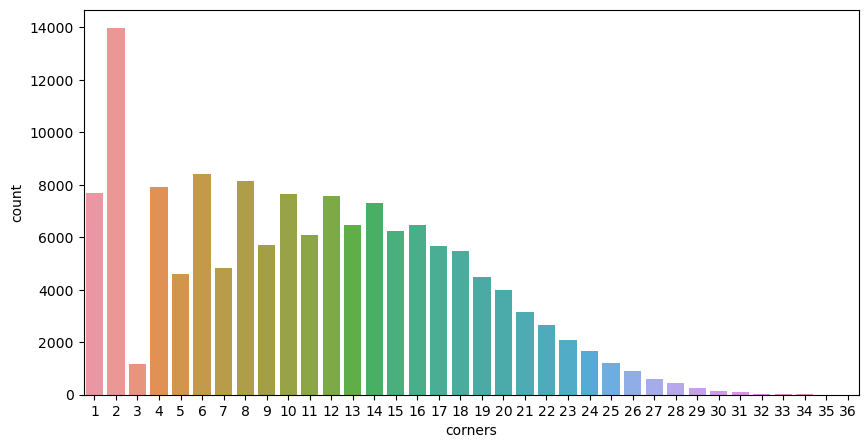

2280


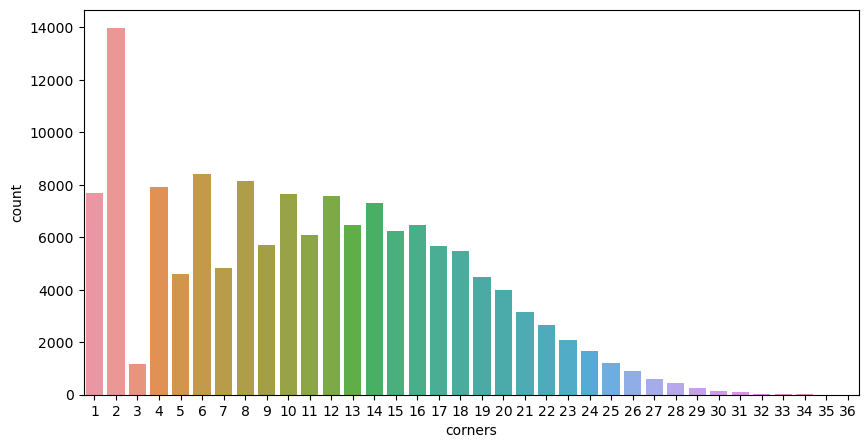

50


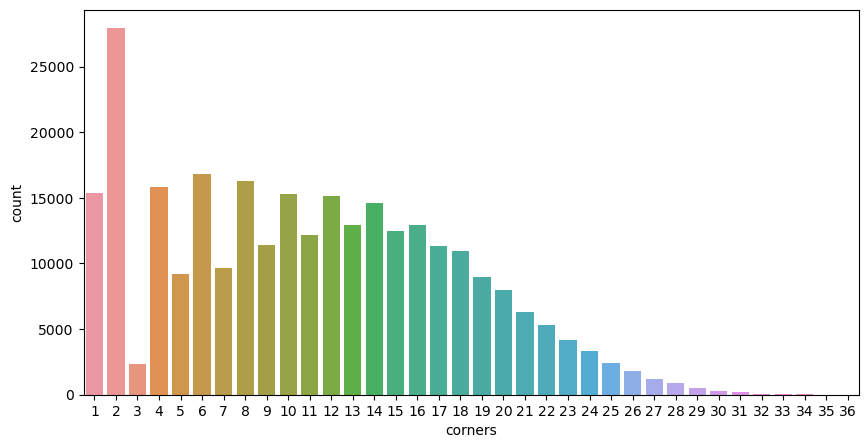

1280


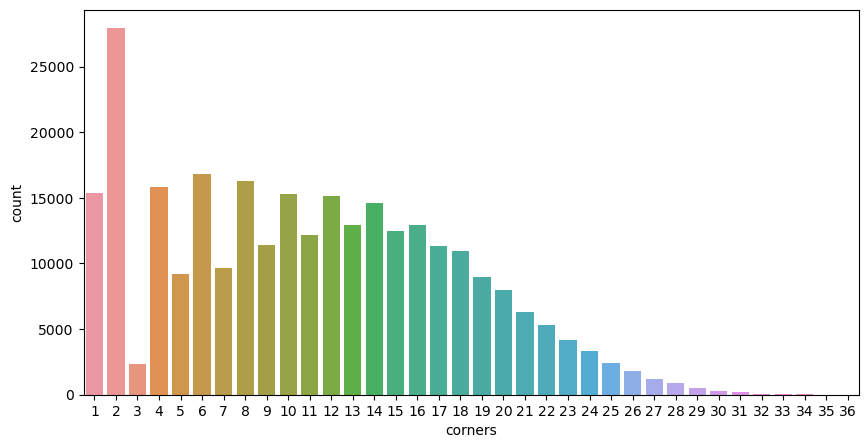

2705


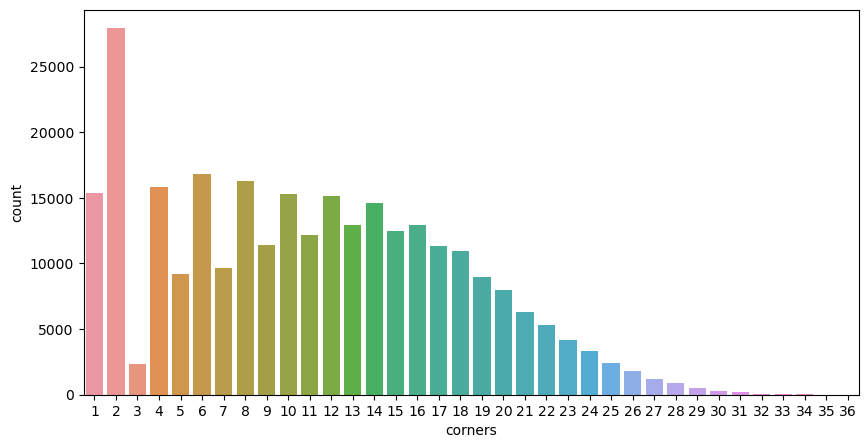

2522


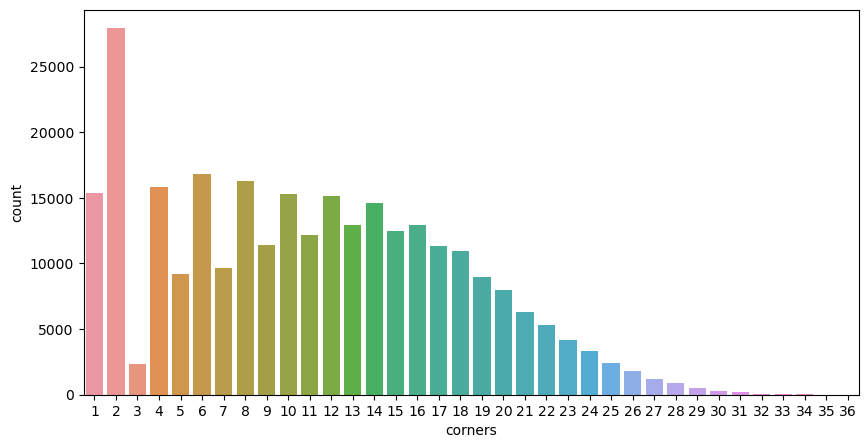

2582


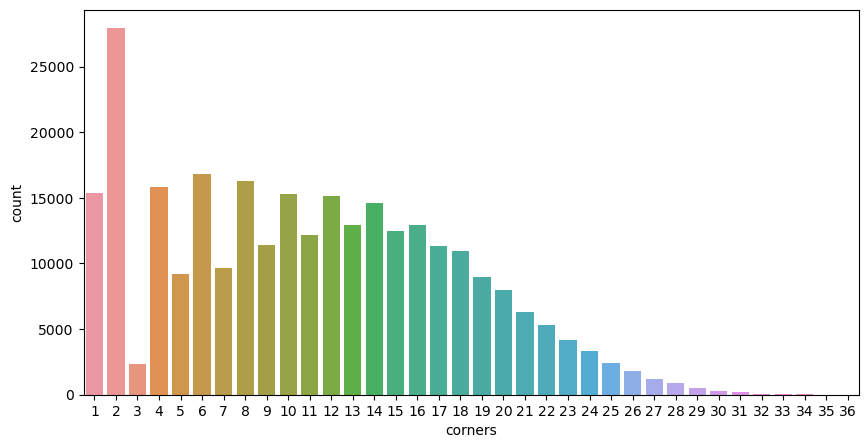

1560


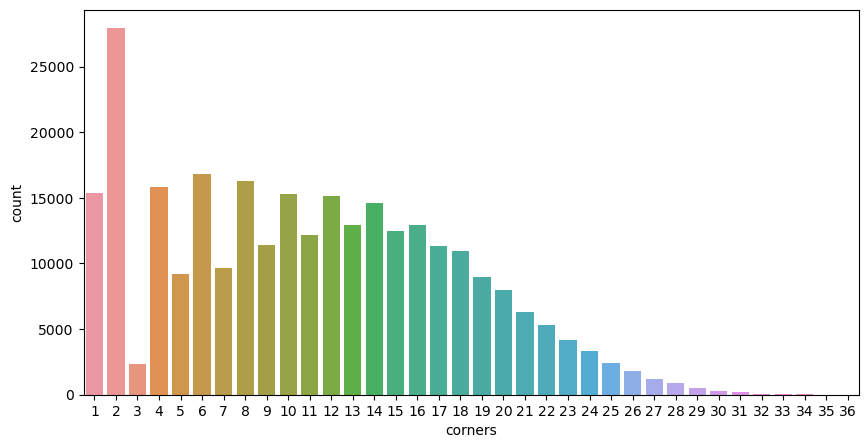

1281


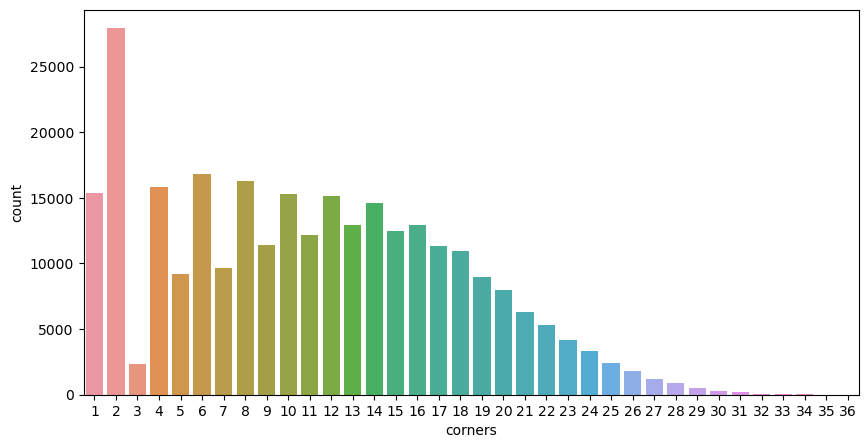

1920


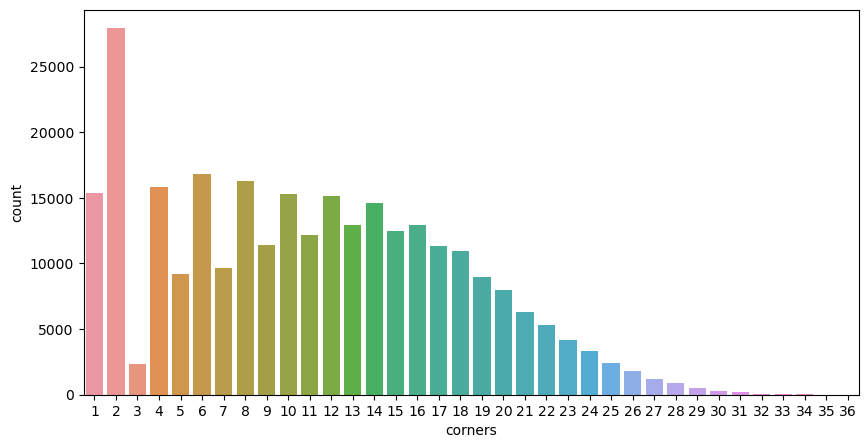

2403


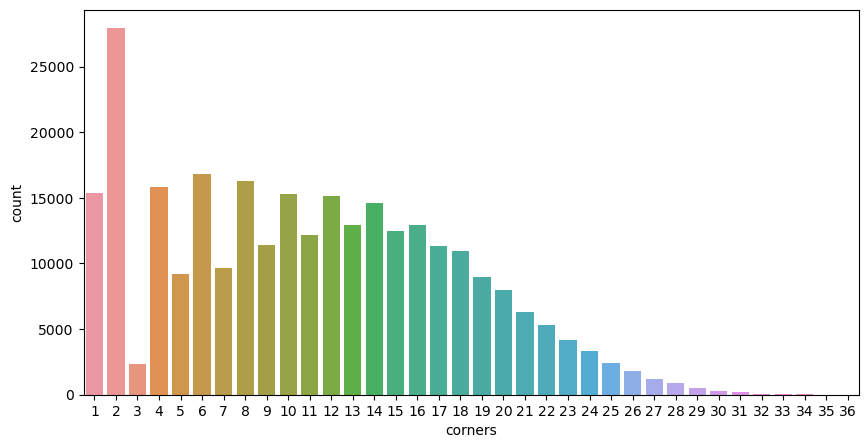

1140


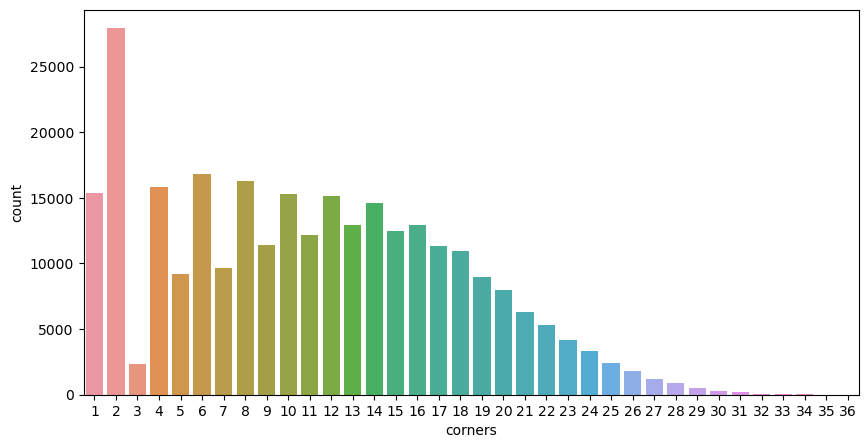

2583


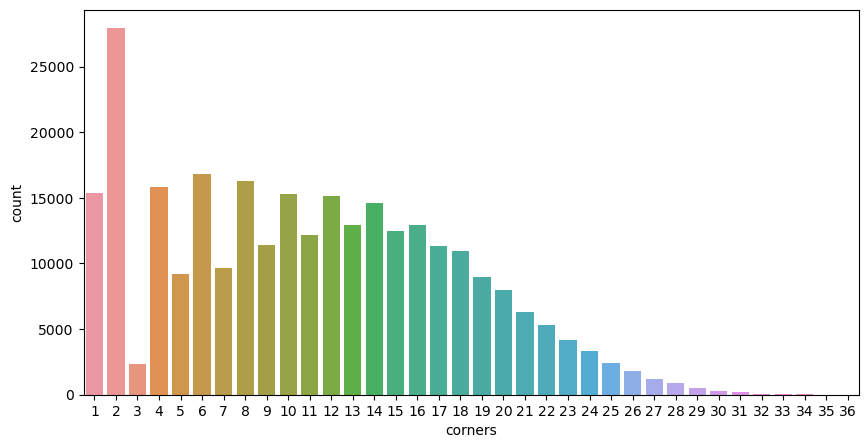

1180


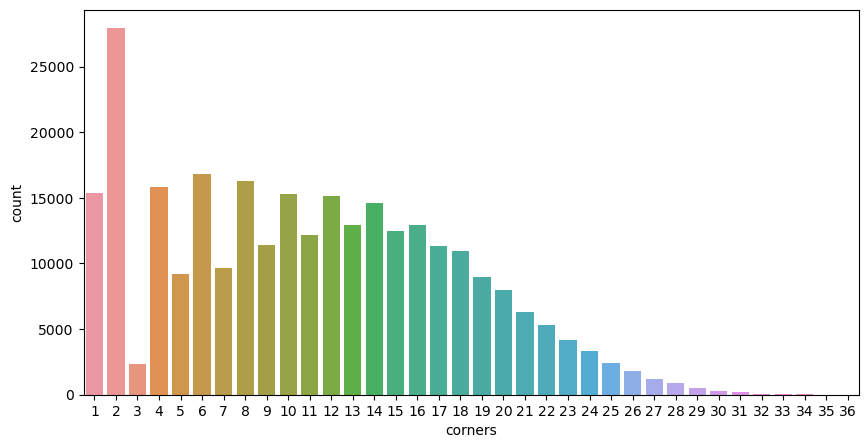

1300


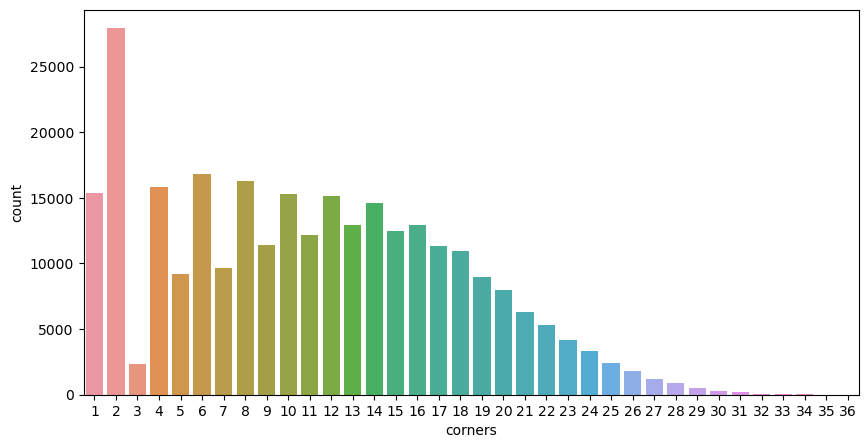

2462


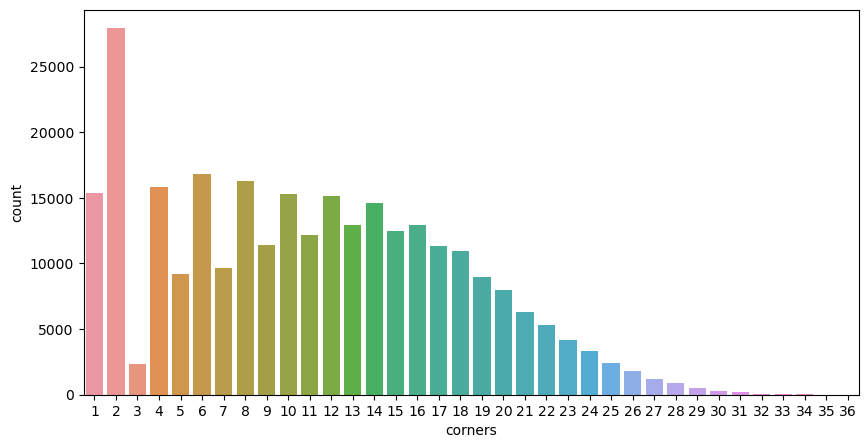

1160


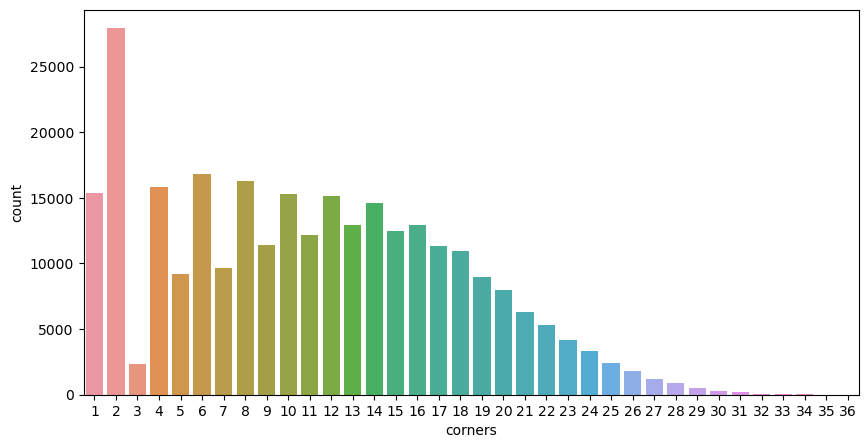

2060


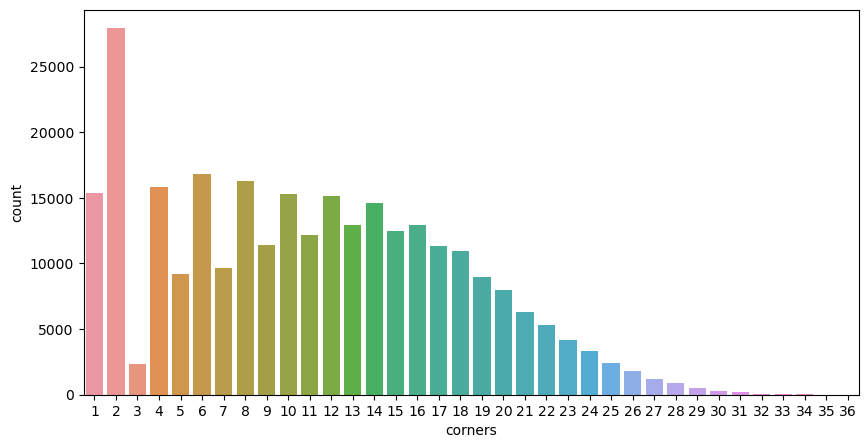

40


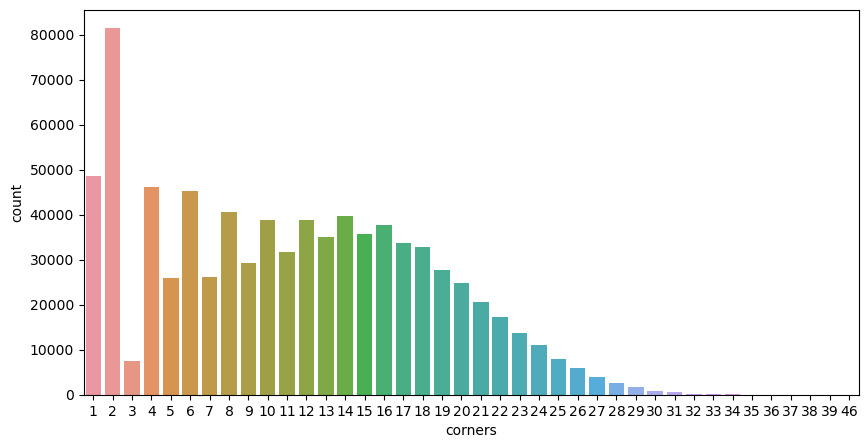

60


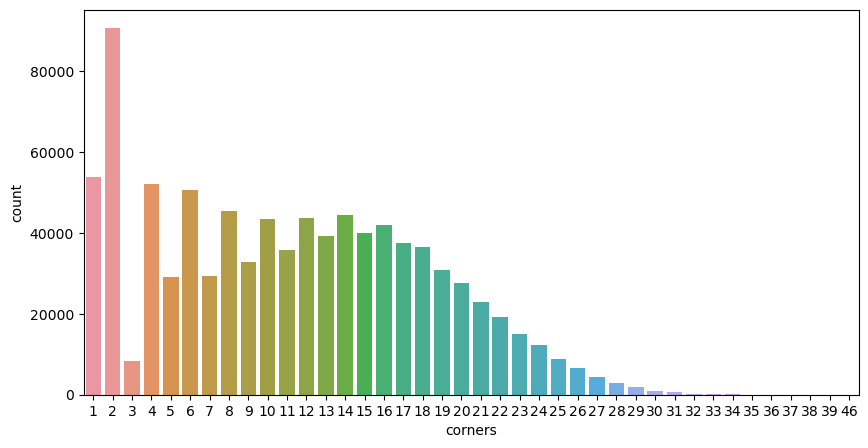

1320


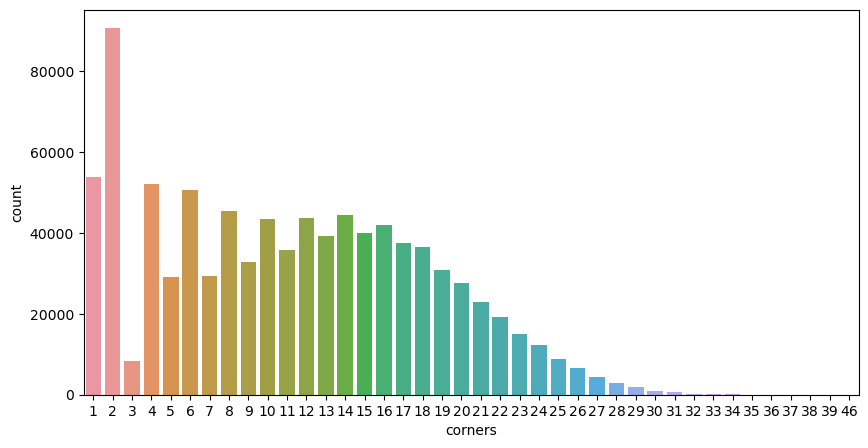

1302


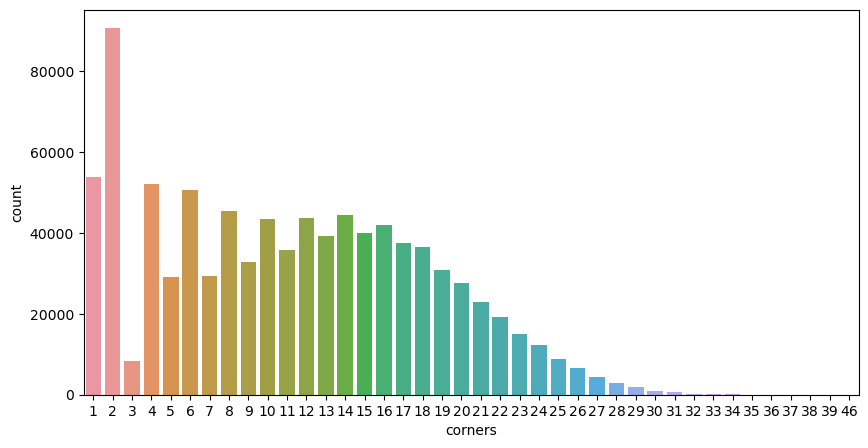

2220


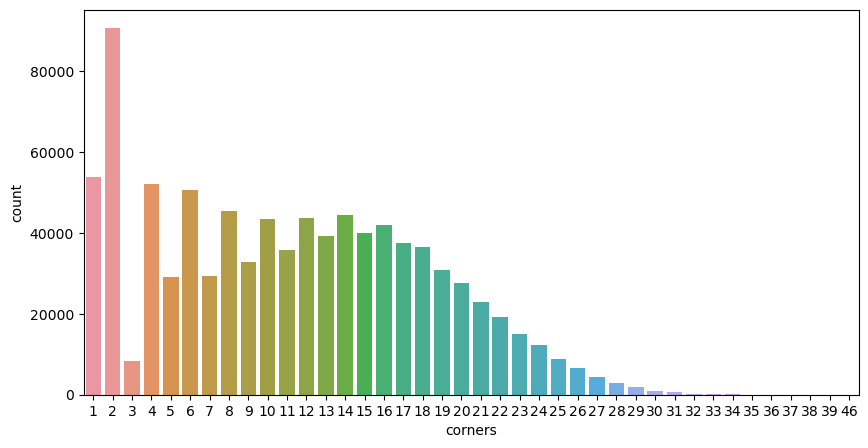

2905


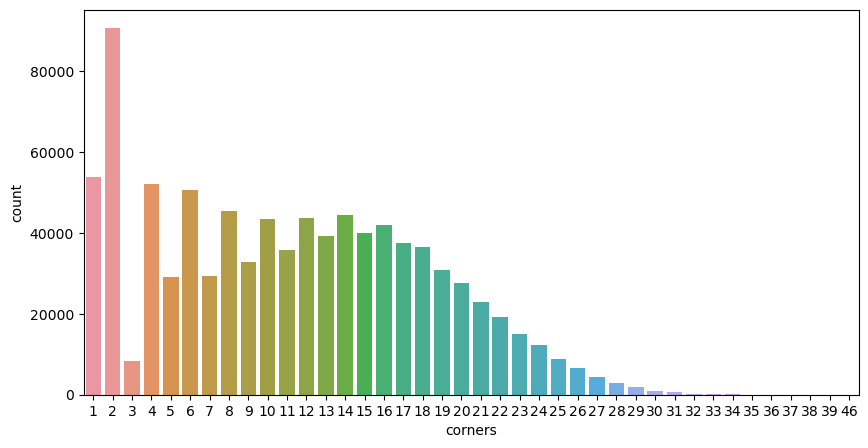

2585


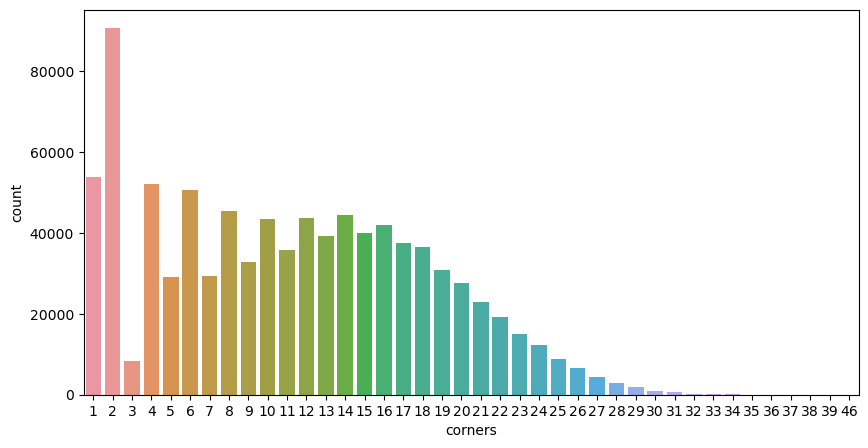

1940


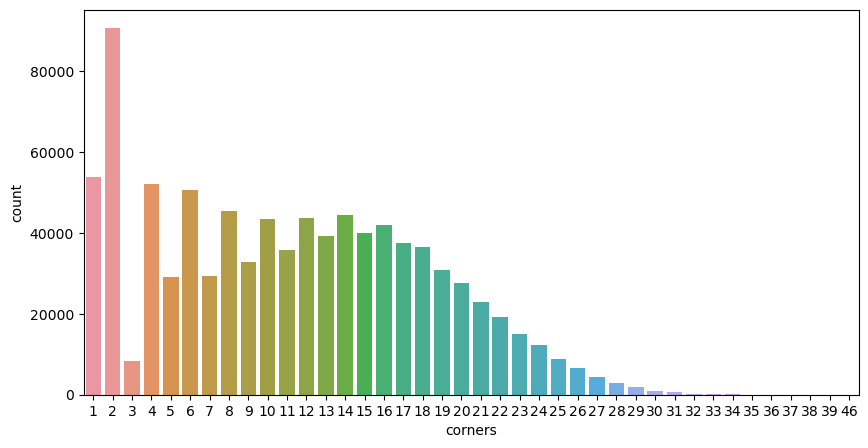

1301


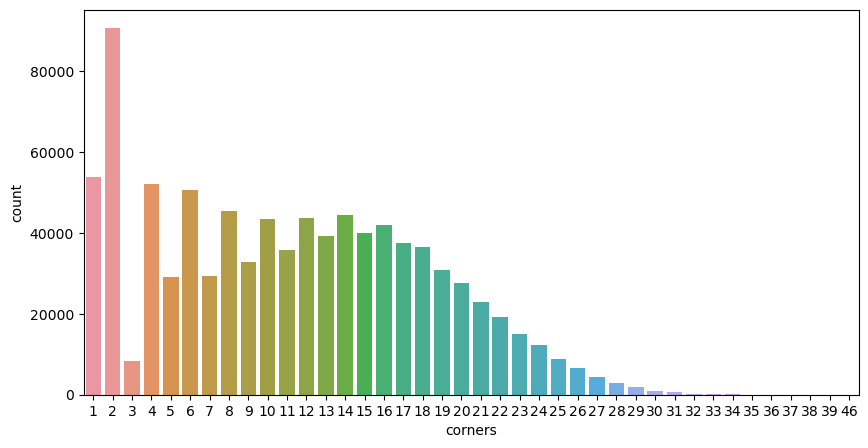

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
for c in cat:
    print(c)
    plt.figure(figsize=(10,5))
    sns.countplot(x=Dfcontour[Dfcontour['prdtypecode']==c]['corners'])
    plt.show()